## Датасет Credit Card Fraud Detection.
Практический проект по построению системы поиска аномалий.

### Часть 0. Подготовка

In [33]:
# Инициализация и логирование

debug = 1  # 1 — выводить отладочные логи, 0 — скрывать

import os
import random
import numpy as np
import pandas as pd
import seaborn as sns
import networkx as nx
import scipy.stats as stats
from datetime import datetime
import matplotlib.pyplot as plt
from IPython.display import HTML, display
from IPython.display import display


In [2]:
# Полезные функции

def log(message):
    if debug == 1:
        # %Y-%m-%d — дата, %H:%M:%S — время
        timestamp = datetime.now().strftime("%Y-%m-%dT%H:%M:%S")
        print(f"[DEBUG] {timestamp} {message}")

log("Функция log готова. Использование: log(message), будет отображено при включенной отладке.")

def show(df):
    if df is None or df.empty:
        log("Ошибочный вызов show(): датафрейм пуст.")
        return
    df_show = df.iloc[0:5].copy()
    if 'name' in df_show.columns:
        df_show['name'] = "Данные скрыты"
    display(df_show)

log("Функция show готова. Использование: show(df), значения в столбце name будут скрыты, отображена таблица с примером наполнения.")

def load_excel_file(file_path):
    try:
        # Проверяем, является ли путь директорией (папкой)
        if os.path.isdir(file_path):
            log(f"Указан путь к папке. Ищем файлы внутри: {file_path}")
            valid_files = [f for f in os.listdir(file_path) if f.endswith(('.csv', '.xlsx', '.xls'))]
            
            if not valid_files:
                log(f"Ошибка: В папке {file_path} не найдено файлов .csv или .xlsx")
                return None
            
            # Берем первый найденный файл, как в вашем примере files[0]
            chosen_file = valid_files[0]
            log(f"Автоматически выбран файл: {chosen_file}")
            file_path = os.path.join(file_path, chosen_file)

        # ---------------------------------------------------------
        # Умное чтение с определением индекса Kaggle / тех. колонок
        # ---------------------------------------------------------
        # Читаем только первые 2 строки, чтобы быстро проверить имена колонок
        if file_path.endswith('.csv'):
            preview = pd.read_csv(file_path, nrows=2)
        else:
            preview = pd.read_excel(file_path, nrows=2)
            
        first_col = preview.columns[0]
        
        # Если первая колонка безымянная (Unnamed) или явно техническая (id, index)
        if "unnamed" in first_col.lower() or first_col.lower() in ['id', 'index', 'uuid']:
            log(f"Обнаружена индексная колонка '{first_col}'. Загружаем с index_col=0.")
            kwargs = {'index_col': 0}
        else:
            kwargs = {}

        # Финальная загрузка всего файла
        if file_path.endswith('.csv'):
            df = pd.read_csv(file_path, **kwargs)
        else:
            df = pd.read_excel(file_path, **kwargs)
        # ---------------------------------------------------------
        
        # Приводим оставшиеся колонки к нижнему регистру и убираем пробелы
        df.columns = [str(col).lower().strip() for col in df.columns]
        
        # Обрабатываем строковые значения
        for col in df.columns:
            if df[col].dtype == 'object':
                df[col] = df[col].astype(str).str.strip()
                df[col] = df[col].replace({'nan': None, 'null': None, 'None': None, '': None})
        
        log(f"Успешно загружено {len(df)} строк из файла: {file_path}")
        log(f"Колонки: {list(df.columns)}")
        return df
        
    except Exception as e:
        log(f"Ошибка при загрузке файла/папки {file_path}: {e}")
        return None

log("Функция load_excel_file готова. Использование: load_excel_file(путь к файлу). Возвращает df.")



[DEBUG] 2026-09-14T14:50:30 Функция log готова. Использование: log(message), будет отображено при включенной отладке.
[DEBUG] 2026-09-14T14:50:30 Функция show готова. Использование: show(df), значения в столбце name будут скрыты, отображена таблица с примером наполнения.
[DEBUG] 2026-09-14T14:50:30 Функция load_excel_file готова. Использование: load_excel_file(путь к файлу). Возвращает df.


### Часть 1. Пишем симуляцию.

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vikalpdongre/us-flights-data-2008")

print("Path to dataset files:", path)


Path to dataset files: C:\Users\oevlannikov\.cache\kagglehub\datasets\vikalpdongre\us-flights-data-2008\versions\1


In [5]:
df = pd.read_csv(f"{path}/2008.csv")
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7009728 entries, 0 to 7009727
Data columns (total 29 columns):
 #   Column             Dtype  
---  ------             -----  
 0   Year               int64  
 1   Month              int64  
 2   DayofMonth         int64  
 3   DayOfWeek          int64  
 4   DepTime            float64
 5   CRSDepTime         int64  
 6   ArrTime            float64
 7   CRSArrTime         int64  
 8   UniqueCarrier      object 
 9   FlightNum          int64  
 10  TailNum            object 
 11  ActualElapsedTime  float64
 12  CRSElapsedTime     float64
 13  AirTime            float64
 14  ArrDelay           float64
 15  DepDelay           float64
 16  Origin             object 
 17  Dest               object 
 18  Distance           int64  
 19  TaxiIn             float64
 20  TaxiOut            float64
 21  Cancelled          int64  
 22  CancellationCode   object 
 23  Diverted           int64  
 24  CarrierDelay       float64
 25  WeatherDelay      

,Year,Month,DayofMonth,DayOfWeek,DepTime,CRSDepTime,ArrTime,CRSArrTime,UniqueCarrier,FlightNum,...,TaxiIn,TaxiOut,Cancelled,CancellationCode,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
0,2008,1,3,4,2003.0,1955,2211.0,2225,WN,335,...,4.0,8.0,0,NaN,0,NaN,NaN,NaN,NaN,NaN
1,2008,1,3,4,754.0,735,1002.0,1000,WN,3231,...,5.0,10.0,0,NaN,0,NaN,NaN,NaN,NaN,NaN
2,2008,1,3,4,628.0,620,804.0,750,WN,448,...,3.0,17.0,0,NaN,0,NaN,NaN,NaN,NaN,NaN
3,2008,1,3,4,926.0,930,1054.0,1100,WN,1746,...,3.0,7.0,0,NaN,0,NaN,NaN,NaN,NaN,NaN
4,2008,1,3,4,1829.0,1755,1959.0,1925,WN,3920,...,3.0,10.0,0,NaN,0,2.0,0.0,0.0,0.0,32.0


В таком формате работать неудобно, каждый раз придётся конкатинировать строки и можно ошибиться, поля из частей временных полей объединим в одно поле времени вылета.

In [7]:
# 1. Приводим время к строке, дополняя нулями до 4 знаков (например, 730 -> '0730', 1430.0 -> '1430')
def format_time(series):
    # Превращаем во float, затем в int (чтобы убрать .0), затем в строку и дополняем нулями
    return series.fillna(0).astype(float).astype(int).astype(str).str.zfill(4)

dep_time_str = format_time(df['DepTime'])
arr_time_str = format_time(df['ArrTime'])

# 2. Собираем полноценную строку даты и времени
# Формат: 'YYYY-MM-DD HH:MM'
datetime_string = (
    df['Year'].astype(str) + '-' +
    df['Month'].astype(str) + '-' +
    df['DayofMonth'].astype(str) + ' ' +
    dep_time_str.str[:2] + ':' + dep_time_str.str[2:]
)

arr_datetime_string = (
    df['Year'].astype(str) + '-' +
    df['Month'].astype(str) + '-' +
    df['DayofMonth'].astype(str) + ' ' +
    arr_time_str.str[:2] + ':' + arr_time_str.str[2:]
)

# 3. Конвертируем в честный datetime и сортируем датасет
df['DepDateTime'] = pd.to_datetime(datetime_string, errors='coerce')
df['ArrDateTime'] = pd.to_datetime(arr_datetime_string, errors='coerce')

# 4. Корректировка ночных рейсов: если время прилета меньше времени вылета, значит рейс прилетел на следующий день
is_next_day = df['ArrDateTime'] < df['DepDateTime']
df.loc[is_next_day, 'ArrDateTime'] += pd.Timedelta(days=1)



In [9]:
# Теперь удаляем лищние артефакты
cols_to_delete = [
    "Year",
    "Month",
    "DayofMonth",
    "DayOfWeek",
    "DepTime",
    "CRSDepTime",
    "ArrTime",
    "CRSArrTime",
]

# Удаляем ненужные столбцы
df.drop(columns=cols_to_delete, inplace=True)

# Вырезаем новые столбцы и ставим их на 1-е и 2-е место
col_dep = df.pop("DepDateTime")
df.insert(0, "DepDateTime", col_dep)

col_arr = df.pop("ArrDateTime")
df.insert(1, "ArrDateTime", col_arr)

df.head()

,DepDateTime,ArrDateTime,UniqueCarrier,FlightNum,TailNum,ActualElapsedTime,CRSElapsedTime,AirTime,ArrDelay,DepDelay,...,TaxiIn,TaxiOut,Cancelled,CancellationCode,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
0,2008-01-03 20:03:00,2008-01-03 22:11:00,WN,335,N712SW,128.0,150.0,116.0,-14.0,8.0,...,4.0,8.0,0,NaN,0,NaN,NaN,NaN,NaN,NaN
1,2008-01-03 07:54:00,2008-01-03 10:02:00,WN,3231,N772SW,128.0,145.0,113.0,2.0,19.0,...,5.0,10.0,0,NaN,0,NaN,NaN,NaN,NaN,NaN
2,2008-01-03 06:28:00,2008-01-03 08:04:00,WN,448,N428WN,96.0,90.0,76.0,14.0,8.0,...,3.0,17.0,0,NaN,0,NaN,NaN,NaN,NaN,NaN
3,2008-01-03 09:26:00,2008-01-03 10:54:00,WN,1746,N612SW,88.0,90.0,78.0,-6.0,-4.0,...,3.0,7.0,0,NaN,0,NaN,NaN,NaN,NaN,NaN
4,2008-01-03 18:29:00,2008-01-03 19:59:00,WN,3920,N464WN,90.0,90.0,77.0,34.0,34.0,...,3.0,10.0,0,NaN,0,2.0,0.0,0.0,0.0,32.0


In [11]:
# Получаем все уникальные аэропорты из датасета
all_airports = pd.concat([df['Origin'], df['Dest']]).unique()

# Принудительно ставим 'ABE' (Allentown) на нулевое место, а остальные сдвигаем
airports_list = ['ABE'] + [port for port in all_airports if port != 'ABE']

# Создаем словарь маппинга: {0: 'ABE', 1: 'IAD', 2: 'IND', ...}
id_to_code = {id_: code for id_, code in enumerate(airports_list)}

In [12]:
print(id_to_code)

{0: 'ABE', 1: 'IAD', 2: 'IND', 3: 'ISP', 4: 'JAN', 5: 'JAX', 6: 'LAS', 7: 'LAX', 8: 'LBB', 9: 'LIT', 10: 'MAF', 11: 'MCI', 12: 'MCO', 13: 'MDW', 14: 'MHT', 15: 'MSY', 16: 'OAK', 17: 'OKC', 18: 'OMA', 19: 'ONT', 20: 'ORF', 21: 'PBI', 22: 'PDX', 23: 'PHL', 24: 'PHX', 25: 'PIT', 26: 'PVD', 27: 'RDU', 28: 'RNO', 29: 'RSW', 30: 'SAN', 31: 'SAT', 32: 'SDF', 33: 'SEA', 34: 'SFO', 35: 'SJC', 36: 'SLC', 37: 'SMF', 38: 'SNA', 39: 'STL', 40: 'TPA', 41: 'TUL', 42: 'TUS', 43: 'ABQ', 44: 'ALB', 45: 'AMA', 46: 'AUS', 47: 'BDL', 48: 'BHM', 49: 'BNA', 50: 'BOI', 51: 'BUF', 52: 'BUR', 53: 'BWI', 54: 'CLE', 55: 'CMH', 56: 'CRP', 57: 'DAL', 58: 'DEN', 59: 'DTW', 60: 'ELP', 61: 'FLL', 62: 'GEG', 63: 'HOU', 64: 'HRL', 65: 'ROC', 66: 'DAY', 67: 'ORD', 68: 'EWR', 69: 'SYR', 70: 'IAH', 71: 'LFT', 72: 'MKE', 73: 'CHS', 74: 'LCH', 75: 'CLT', 76: 'BTR', 77: 'CRW', 78: 'FAT', 79: 'COS', 80: 'MRY', 81: 'LGB', 82: 'BFL', 83: 'EUG', 84: 'ICT', 85: 'MEM', 86: 'LGA', 87: 'DCA', 88: 'BTV', 89: 'GRK', 90: 'BRO', 91: 'TYS

In [29]:
def simulate_flight_infection(df, start_node=0, p=0.05, mapping=id_to_code):
    """
    Симуляция одного прохода по всему датасету для распространения инфекции.
    
    :param df: Pandas DataFrame (уже отсортированный по 'DepDateTime'!)
    :param start_node: ID стартового аэропорта (инт, например Allentown = 0)
    :param p: Вероятность заражения при контакте (0.0 <= p <= 1.0)
    :param mapping: Словарь {ID: 'КОД'} для связи с датасетом
    :return: Словарь {Время_заражения: 'Название_аэропорта'}
    """
    # Определяем строковый код стартового аэропорта по его ID
    start_airport_code = mapping[start_node]
    
    # Внутреннее хранилище: {'КОД_АЭРОПОРТА': Время_Заражения}
    # Используем минимально возможное время, чтобы стартовая точка была активна сразу
    infected_internal = {start_airport_code: pd.Timestamp.min}
    
    # Итерируемся по датасету через быстрый itertuples
    for row in df.itertuples():
        # Игнорируем отмененные и перенаправленные рейсы, так как они не прилетели
        if getattr(row, 'Cancelled', 0) == 1 or getattr(row, 'Diverted', 0) == 1:
            continue
            
        origin = row.Origin
        dest = row.Dest
        dep_time = row.DepDateTime
        arr_time = row.ArrDateTime
        
        # Условие 1: Аэропорт вылета заражен И рейс вылетел ПОСЛЕ его заражения
        if origin in infected_internal and dep_time >= infected_internal[origin]:
            
            # Условие 2: Аэропорт прилета еще НЕ заражен
            if dest not in infected_internal:
                
                # Условие 3: Срабатывание случайной вероятности p
                if random.random() <= p:
                    infected_internal[dest] = arr_time
                    
    # Формируем красивый выходной словарь по требованию задачи: {Время: Аэропорт}
    result = {}
    for airport_code, time in infected_internal.items():
        # Для стартового аэропорта пишем время самого первого рейса в симуляции
        actual_time = df['DepDateTime'].min() if time == pd.Timestamp.min else time
        
        if actual_time not in result:
            result[actual_time] = []
        result[actual_time].append(airport_code)
        
            
    # Возвращаем словарь, отсортированный по хронологии заражения
    return dict(sorted(result.items()))


In [27]:
im = 'infected.png'

In [30]:
# Сортируем по времени вылета, иначе симуляция сломает хронологию
df_sorted = df.sort_values('DepDateTime').reset_index(drop=True)

# Запуск: стартуем с ноды 0 (Allentown), вероятность заражения рейса — 10%
infection_log = simulate_flight_infection(df_sorted, start_node=0, p=0.10)

# Выводим результаты
print("\nПервые 10 заражений:")
for time, airport in list(infection_log.items())[:10]:
    # Создаем HTML-строку, где картинка и текст выровнены по вертикали
    html_string = f"""
    <div style="display: flex; align-items: center; gap: 8px; margin-bottom: 6px;">
        <img src="{im}" style="height: 20px; width: auto; max-width: none;" />
        <span>{time} Заражен аэропорт: <strong>{airport}</strong></span>
    </div>
    """
    # Отображаем HTML-верстку в интерфейсе Jupyter
    display(HTML(html_string))

print(f"Всего заражено аэропортов: {len(infection_log)}")


Первые 10 заражений:


Всего заражено аэропортов: 283


## Часть 2. Как инфекционность (вероятность заражения) болезни влияет на скорость распространения?

[DEBUG] 2026-09-14T17:28:54 Запуск симуляций для p = 0.01...
[DEBUG] 2026-09-14T17:36:36 Запуск симуляций для p = 0.05...
[DEBUG] 2026-09-14T17:42:57 Запуск симуляций для p = 0.1...
[DEBUG] 2026-09-14T17:49:05 Запуск симуляций для p = 0.5...
[DEBUG] 2026-09-14T17:55:41 Запуск симуляций для p = 1.0...


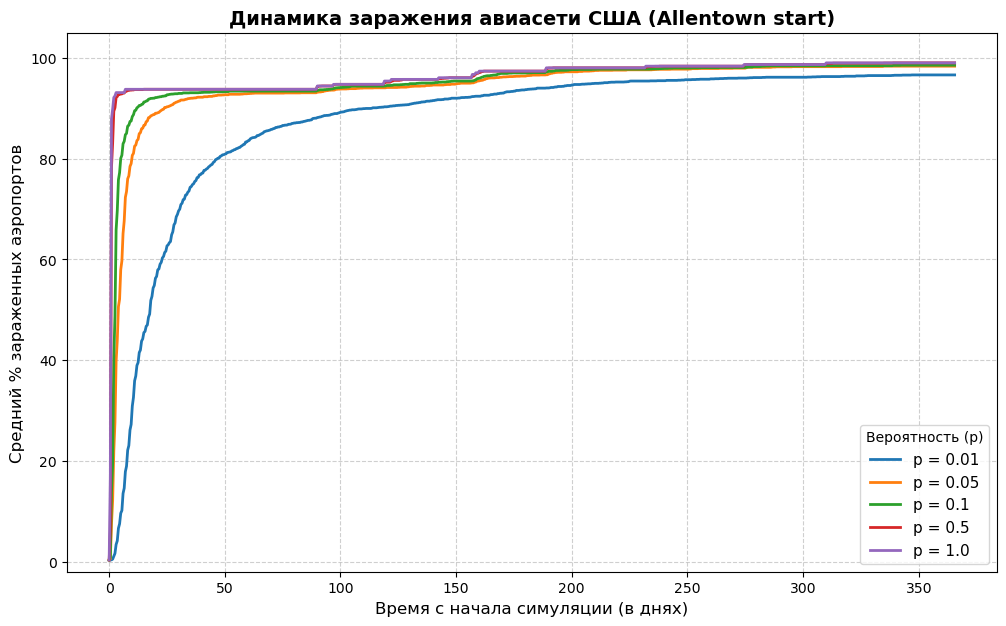

In [32]:


# --- 1. Подготовка параметров эксперимента ---
probabilities = [0.01, 0.05, 0.1, 0.5, 1.0]
num_simulations = 10
total_airports_count = len(airports_list)  # Из предыдущего шага (например, 304)

# Определяем временные границы эксперимента
start_time = df_sorted['DepDateTime'].min()
end_time = df_sorted['DepDateTime'].max()

# Создаем сетку времени с шагом в 12 часов от начала до конца данных
time_grid = pd.date_range(start=start_time, end=end_time, freq='12h')

# Словарь для хранения финальных графиков по каждой вероятности
plot_data = {}

# --- 2. Основной цикл эксперимента ---
for p in probabilities:
    log(f"Запуск симуляций для p = {p}...")
    
    # Сетка для сохранения процента зараженных аэропортов по шагам времени для каждой из 10 симуляций
    # Строки — симуляции (10), колонки — 12-часовые интервалы
    sim_matrix = np.zeros((num_simulations, len(time_grid)))
    
    for sim_idx in range(num_simulations):
        # Запускаем нашу функцию симуляции из предыдущего шага
        # Она возвращает словарь {Время_заражения: Аэропорт}
        infection_log = simulate_flight_infection(df_sorted, start_node=0, p=p)

            # Разворачиваем словарь {Время: [Список]} в плоский список пар (Время, Аэропорт)
        flat_log = []
        for time, airports in infection_log.items():
            for s_airport in airports:
                flat_log.append((time, s_airport))
            
        # Превращаем лог в DataFrame для удобного подсчета кумулятивного итога
        log_df = pd.DataFrame(flat_log, columns=['InfectionTime', 'Airport'])
        log_df = log_df.sort_values('InfectionTime')
        
        # Для каждой точки 12-часовой сетки считаем, сколько аэропортов уже было заражено
        # И делим на общее число аэропортов, чтобы получить процент
        for t_idx, current_t in enumerate(time_grid):
            infected_count = log_df[log_df['InfectionTime'] <= current_t].shape[0]
            percentage = (infected_count / total_airports_count) * 100
            sim_matrix[sim_idx, t_idx] = percentage
            
    # Считаем средний процент по 10 симуляциям для каждого 12-часового интервала
    mean_percentages = sim_matrix.mean(axis=0)
    plot_data[p] = mean_percentages

# --- 3. Построение графиков ---
plt.figure(figsize=(12, 7))

# Считаем относительное время в часах или днях от старта для красивой оси X
hours_from_start = [(t - start_time).total_seconds() / 3600 for t in time_grid]
days_from_start = [h / 24 for h in hours_from_start]

for p, y_data in plot_data.items():
    plt.plot(days_from_start, y_data, label=f'p = {p}', linewidth=2)

plt.title('Динамика заражения авиасети США (Allentown start)', fontsize=14, fontweight='bold')
plt.xlabel('Время с начала симуляции (в днях)', fontsize=12)
plt.ylabel('Средний % зараженных аэропортов', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title="Вероятность (p)", fontsize=11)

# Ограничим ось Y от 0 до 105% для наглядности
plt.ylim(-2, 105)

plt.show()

## Часть 3.  Может ли информация о сети помочь предсказать, кто будет заражен?


[DEBUG] 2026-09-14T19:04:16 Вычисляем метрики графа.


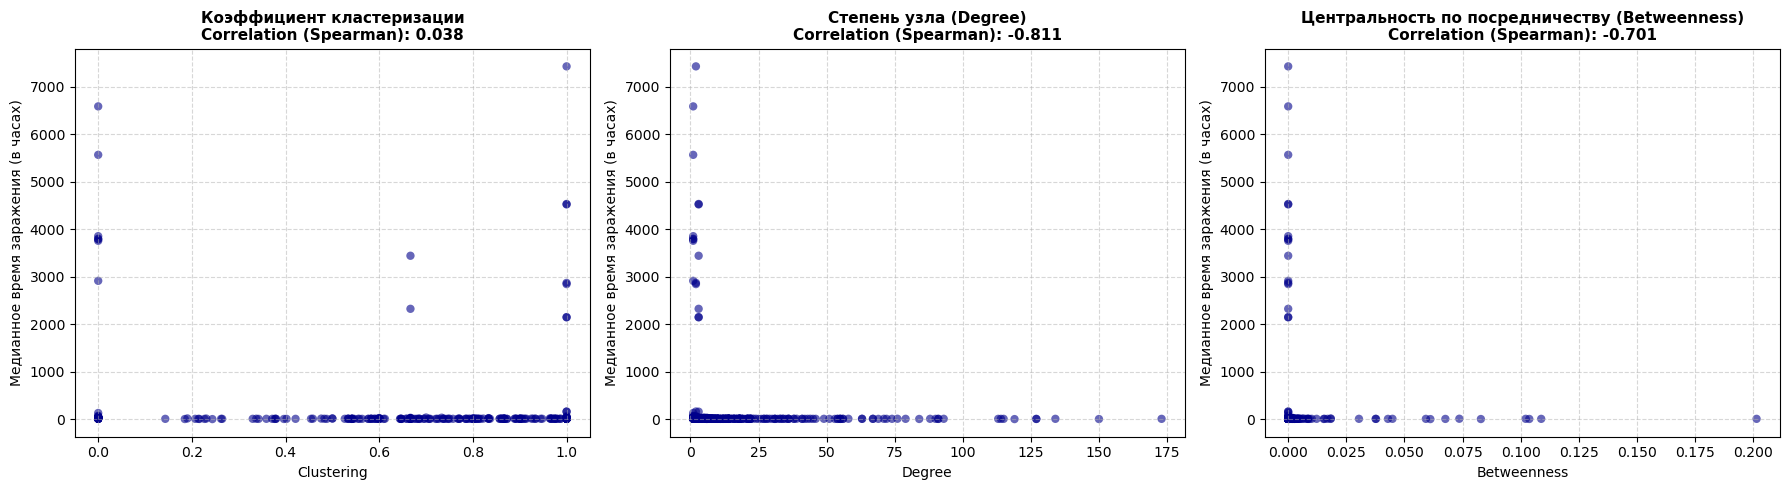

In [36]:
# all_airports содержит список всех кодов (например, из df['origin'].unique())
all_airports = set(df_sorted['Origin'].unique()).union(set(df_sorted['Dest'].unique()))

# --- 1. Построение взвешенного ненаправленного графа ---
N_total = len(df_sorted)

# Чтобы объединить направления А->Б и Б->А, создаем кортеж из отсортированных названий
df_pairs = df_sorted.copy()
df_pairs['pair'] = df_pairs.apply(lambda r: tuple(sorted([r['Origin'], r['Dest']])), axis=1)

# Считаем суммарное количество рейсов между каждой парой городов
edge_counts = df_pairs['pair'].value_counts()

G = nx.Graph()
for (u, v), count in edge_counts.items():
    weight = count / N_total
    G.add_edge(u, v, weight=weight)


# --- 2. Сбор данных из 50 симуляций (при p = 0.5) ---
start_time = df_sorted['DepDateTime'].min()

# Будем сохранять время первого заражения (в часах от старта) каждого аэропорта для всех 50 прогонов
infection_times_accumulator = {port: [] for port in all_airports}

for sim in range(50):
    # Запускаем симуляцию
    infection_log = simulate_flight_infection(df_sorted, start_node=0, p=0.5)
    
    # Записываем время для каждого города в текущей симуляции
    for time, airports in infection_log.items():
        hours_passed = (time - start_time).total_seconds() / 3600.0
        for port in airports:
            infection_times_accumulator[port].append(hours_passed)

# Считаем медианное время заражения для каждого города
median_times = {}
for port, times in infection_times_accumulator.items():
    # Если город ни разу не заразился в каком-то прогоне, берем медиану от успешных заражений
    if times:
        median_times[port] = np.median(times)
    else:
        median_times[port] = np.nan


# --- 3. Расчёт топологических метрик графа ---
log("Вычисляем метрики графа.")
clustering = nx.clustering(G)                       # Коэффициент кластеризации
degree = dict(G.degree())                           # Степень узла (Degree)
betweenness = nx.betweenness_centrality(G)          # Центральность по посредничеству

# Собираем все результаты в итоговый DataFrame
analysis_df = pd.DataFrame(index=list(all_airports))
analysis_df['MedianTime'] = analysis_df.index.map(median_times)
analysis_df['Clustering'] = analysis_df.index.map(clustering)
analysis_df['Degree'] = analysis_df.index.map(degree)
analysis_df['Betweenness'] = analysis_df.index.map(betweenness)

# Убираем стартовый город 'ABE' (у него время всегда 0) и NaN, чтобы не искажать корреляцию
analysis_df = analysis_df.drop(index='ABE', errors='ignore').dropna()


# --- 4. Визуализация (Scatter-plots) и расчёт корреляции Спирмена ---
metrics = ['Clustering', 'Degree', 'Betweenness']
titles = ['Коэффициент кластеризации', 'Степень узла (Degree)', 'Центральность по посредничеству (Betweenness)']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, metric in enumerate(metrics):
    # Вычисляем коэффициент ранговой корреляции Спирмена
    corr, p_value = stats.spearmanr(analysis_df[metric], analysis_df['MedianTime'])
    
    # Строим Scatter-plot
    axes[i].scatter(analysis_df[metric], analysis_df['MedianTime'], alpha=0.6, color='darkblue', edgecolors='none')
    axes[i].set_title(f"{titles[i]}\nCorrelation (Spearman): {corr:.3f}", fontsize=11, fontweight='bold')
    axes[i].set_xlabel(metric)
    axes[i].set_ylabel('Медианное время заражения (в часах)')
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


## Часть 4. Итоги

### 1. Коэффициенты корреляции Спирмана
- Степень узла (Degree) имеет самую сильную корреляцию: -0.811
- Центральность по посредничеству (Betweenness) находится на втором месте: -0.701
- Коэффициент кластеризации (Clustering) практически не связан со временем заражения: 0.038
Отрицательная корреляция здесь означает: чем больше метрика графа, тем меньше времени нужно для заражения (т.е. город заражается быстрее).

### 2. Какая из метрик графа сильнее всего скоррелирована со временем заражения?
Сильнее всего со временем заражения скоррелированы Степень узла (Degree) и Центральность по посредничеству (Betweenness Centrality).

### 3. Почему?
- Степень узла (Degree): Аэропорты с высоким Degree (крупные хабы вроде Атланты ATL или Чикаго ORD) имеют сотни прямых связей с другими городами. Вероятность того, что хотя бы один зараженный самолет прилетит в такой хаб в первые же часы, стремится к 100%. Они служат главными «губками» для инфекции.
- Центральность по посредничеству (Betweenness Centrality): Эта метрика показывает, как часто аэропорт лежит на кратчайших путях между всеми остальными парами городов. Высокий Betweenness гарантирует, что город находится на «главной магистрали» распространения вируса.